In [ ]:
!pip install catboost

In [2]:
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# **CONSTANTS**

In [3]:
TRAIN_DATA_PATH       = '/content/drive/MyDrive/DataColab/Agriculture /crop_remmendation_datasetf(class)/dataSets/crop_remmendation(final_processed_data).csv'

PIPE_LINE_PATH        = '/content/drive/MyDrive/DataColab/Agriculture /crop_remmendation_datasetf(class)/pipeLine/crop_recommendation_pipeline(Preprocessing).joblib'

LABEL_ENCODER_PATH    = '/content/drive/MyDrive/DataColab/Agriculture /crop_remmendation_datasetf(class)/pipeLine/label_encoder(target).joblib'

ONE_HOT_ENCODE_PATH   = '/content/drive/MyDrive/DataColab/Agriculture /crop_remmendation_datasetf(class)/pipeLine/onehot_encoder(features).joblib'

TEST_DATA_PATH        = '/content/drive/MyDrive/DataColab/Agriculture /crop_remmendation_datasetf(class)/dataSets/test_data(crop_remmendation).csv'

**`Important Functions`**

In [ ]:
# @title
def feature_extraction(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create engineered (extracted) features for crop-type recommendation.

    Expected columns:
    N, P, K, Soil_pH, Soil_Moisture, Organic_Carbon, Electrical_Conductivity,
    Temperature, Humidity, Rainfall, Sunlight_Hours, Wind_Speed, Altitude,
    Fertilizer_Used (optional / numeric)
    """
    X = df.copy()
    eps = 1e-9  # to avoid divide-by-zero

    # --- Nutrient (NPK) features ---
    X["NPK_sum"] = X["N"] + X["P"] + X["K"]
    X["N_ratio"] = X["N"] / (X["NPK_sum"] + eps)
    X["P_ratio"] = X["P"] / (X["NPK_sum"] + eps)
    X["K_ratio"] = X["K"] / (X["NPK_sum"] + eps)

    X["N_to_P"] = X["N"] / (X["P"] + 1.0)
    X["N_to_K"] = X["N"] / (X["K"] + 1.0)
    X["P_to_K"] = X["P"] / (X["K"] + 1.0)

    X["NPK_balance"] = X[["N", "P", "K"]].max(axis=1) - X[["N", "P", "K"]].min(axis=1)

    # --- Soil chemistry features ---
    X["pH_distance"] = (X["Soil_pH"] - 7.0).abs()
    X["EC_log"] = np.log1p(X["Electrical_Conductivity"].clip(lower=0))

    # organic carbon context
    X["Fertility_index"] = X["Organic_Carbon"] * (X["NPK_sum"] + eps)
    X["OC_to_NPK"] = X["Organic_Carbon"] / (X["NPK_sum"] + 1.0)

    # --- Water / climate interaction features ---
    X["Moisture_Rain"] = X["Soil_Moisture"] * X["Rainfall"]
    X["Temp_Humidity"] = X["Temperature"] * X["Humidity"]
    X["Heat_Load"] = X["Temperature"] * X["Sunlight_Hours"]
    X["SunRain_ratio"] = X["Sunlight_Hours"] / (X["Rainfall"] + 1.0)
    X["Dryness_Index"] = X["Temperature"] / (X["Humidity"] + 1.0)

    # --- Geography interaction ---
    X["Altitude_Temp"] = X["Altitude"] * X["Temperature"]

    # --- Fertilizer interaction (only if Fertilizer_Used is numeric) ---
    if "Fertilizer_Used" in X.columns and pd.api.types.is_numeric_dtype(X["Fertilizer_Used"]):
        X["Fert_NPK_interaction"] = X["Fertilizer_Used"] * (X["NPK_sum"] + eps)

    return X


###################################

def Encode(df_origin : pd.DataFrame) -> pd.DataFrame :


  loaded_encoder = joblib.load(ONE_HOT_ENCODE_PATH)

  df_num = df_origin.select_dtypes(include = ['int64' , 'float64' ])
  df_cat = df_origin.select_dtypes(include = ['object'])

  df_cat_encoder_array = loaded_encoder.transform(df_cat)
  df_encoder_dataFrame = pd.DataFrame(df_cat_encoder_array , columns = loaded_encoder.get_feature_names_out(df_cat.columns))

  x = pd.concat(
      [df_num, df_encoder_dataFrame],
      axis=1
  )
  return x

#################################
def feature_selection(feature_with_extract: pd.DataFrame) -> pd.DataFrame:
  x = feature_with_extract[['Temperature', 'SunRain_ratio', 'Moisture_Rain', 'Dryness_Index',
      'Heat_Load', 'Temp_Humidity', 'Soil_pH', 'N', 'Altitude_Temp',
      'pH_distance', 'Season_Rabi', 'N_ratio', 'N_to_P', 'NPK_balance',
      'NPK_sum', 'K_ratio', 'N_to_K', 'Soil_Type_Sandy', 'OC_to_NPK']]
  return x

> ---

# **PreModel**

In [10]:
df = pd.read_csv( TRAIN_DATA_PATH )
pipe = joblib.load( PIPE_LINE_PATH ) # for test data
label_encoder = joblib.load( LABEL_ENCODER_PATH )

AttributeError: Can't get attribute 'Encode' on <module '__main__'>

In [ ]:
df_test_transformed = pipe.transform(pd.read_csv(TEST_DATA_PATH).drop('Recommended_Crop' , axis =1 ))
column_names = [f'LD{i+1}' for i in range(df_test_transformed.shape[1])]
df_test = pd.DataFrame(df_test_transformed, columns=column_names)
target_test = label_encoder.transform(pd.read_csv(TEST_DATA_PATH)['Recommended_Crop'])
df_test['target'] = target_test

In [ ]:
pipe

Pipeline(steps=[('Encoding',
                 FunctionTransformer(func=<function Encode at 0x7be5a1778680>)),
                ('FeaturesExtract',
                 FunctionTransformer(func=<function feature_extraction at 0x7be5a17784a0>)),
                ('FeaturesSelect',
                 FunctionTransformer(func=<function feature_selection at 0x7be5a1778720>)),
                ('PowerTransform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('PowerTransform',
                                                  PowerTransformer(),
                                                  ['Temperature',
                                                   'SunRain_ratio',
                                                   'Moisture_Rain',
                                                   'Dryness_Index', 'Heat_Load',
                                                   'Temp_Humidity', 'Soil_pH',
                                                   'N', 'Altitude_Temp',
                                                   'pH_distance', 'N_ratio',
                                                   'N_to_P', 'NPK_balance',
                                                   'NPK_sum', 'K_ratio',
                                                   'N_to_K', 'OC_to_NPK'])])),
                ('LDA', LinearDiscriminantAnalysis(n_components=9))])

In [ ]:
df.head()

,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8,LD9,target
0,2.705517,1.043451,-2.325842,-0.265080,-0.153016,0.576329,-0.914319,0.229731,-0.363052,6
1,1.183871,0.294492,1.311305,-1.922766,-0.699789,-0.870149,-0.954513,0.794721,-0.280757,6
2,-4.076827,1.455201,1.609056,1.240158,1.130050,-0.106601,-1.486629,0.827093,0.553869,9
3,-0.236668,-0.736233,0.459595,1.318138,-0.973054,-0.386289,-0.832243,1.126196,1.745144,0
4,2.286663,0.289125,0.348703,-1.414179,-0.040101,-0.402979,-1.298652,1.700397,-1.148789,6


In [ ]:
df_test.head()

,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8,LD9,target
0,-3.293221,-0.002133,1.145658,-0.558489,-1.088427,-1.026959,-0.191747,0.399977,2.098659,9
1,-1.144750,-1.598251,0.335744,0.362188,-1.137142,-1.438162,-0.293342,1.257307,-0.443251,6
2,-0.383814,1.106411,0.496689,-0.054364,-1.544649,1.840625,-0.930627,-0.991860,-0.073870,3
3,0.013795,-0.698297,1.564206,0.176731,1.131200,-0.150311,0.886730,0.344754,-1.339845,9
4,1.785368,-0.149348,-2.392957,-0.040815,-0.435847,1.112967,0.312096,-0.078090,0.588356,6


# **First Model**

In [ ]:
df_first_model= df.copy()
df_first_model['target'].value_counts()
df_first_model['target'] = df_first_model['target'].apply(lambda x: x if x in [6, 9] else -1)
df_first_model = df_first_model.groupby('target').sample(1800)


df_first_model_test= df_test.copy()
df_first_model_test['target'].value_counts()
df_first_model_test['target'] = df_first_model_test['target'].apply(lambda x: x if x in [6, 9] else -1)
# df_first_model_test = df_first_model_test.groupby('target').sample(1800)

In [ ]:
df_first_model['target'].value_counts()

,count
target,
-1,1800
6,1800
9,1800


In [ ]:
x_1 = df_first_model.drop('target' , axis = 1)
y_1 = df_first_model['target']

## **Train First Model (NOT FINAL)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x_1,
    y_1,
    test_size=0.2,
    random_state=42,
    stratify=y_1
)

In [ ]:
model = CatBoostClassifier(
    iterations=3000,              # allow many trees, but early stopping will choose best
    depth=6,                      # lower than 10 to reduce overfitting
    learning_rate=0.02,           # smaller learning rate
    loss_function="MultiClass",
    eval_metric="Accuracy",

    # Regularization
    l2_leaf_reg=10,               # L2 regularization; try 5, 10, 20, 30
    random_strength=2,            # adds randomness to splits; try 1-5
    bagging_temperature=1,        # Bayesian bootstrap regularization; try 0.5-5
    rsm=0.8,                      # feature sampling per tree; like max_features
    min_data_in_leaf=20,          # prevents leaves with very few samples

    # Anti-overfit
    od_type="Iter",
    od_wait=100,                  # early stopping patience
    use_best_model=True,

    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

In [ ]:
model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test)
)

0:	learn: 0.7935185	test: 0.7787037	best: 0.7787037 (0)	total: 72.7ms	remaining: 3m 38s
100:	learn: 0.8432870	test: 0.8259259	best: 0.8268519 (93)	total: 1.73s	remaining: 49.6s
200:	learn: 0.8648148	test: 0.8388889	best: 0.8398148 (198)	total: 3.35s	remaining: 46.7s
300:	learn: 0.8740741	test: 0.8425926	best: 0.8425926 (282)	total: 5.71s	remaining: 51.2s
400:	learn: 0.8803241	test: 0.8462963	best: 0.8462963 (354)	total: 8.42s	remaining: 54.6s
500:	learn: 0.8872685	test: 0.8481481	best: 0.8490741 (486)	total: 10.9s	remaining: 54.3s
600:	learn: 0.8923611	test: 0.8509259	best: 0.8518519 (567)	total: 12.7s	remaining: 50.7s
700:	learn: 0.8953704	test: 0.8546296	best: 0.8546296 (619)	total: 14.5s	remaining: 47.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8546296296
bestIteration = 619

Shrink model to first 620 iterations.


CatBoostClassifier(allow_writing_files=False, bagging_temperature=1, depth=6, eval_metric='Accuracy', iterations=3000, l2_leaf_reg=10, learning_rate=0.02, loss_function='MultiClass', min_data_in_leaf=20, od_type='Iter', od_wait=100, random_seed=42, random_strength=2, rsm=0.8, use_best_model=True, verbose=100)

In [ ]:
y_train_pred = model.predict(X_train).ravel()
y_test_pred = model.predict(X_test).ravel()

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Gap:", train_accuracy - test_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Train Accuracy: 0.892824074074074
Test Accuracy: 0.8546296296296296
Gap: 0.03819444444444442

Classification Report:
              precision    recall  f1-score   support

          -1       0.80      0.83      0.81       360
           6       0.91      0.91      0.91       360
           9       0.85      0.82      0.84       360

    accuracy                           0.85      1080
   macro avg       0.86      0.85      0.85      1080
weighted avg       0.86      0.85      0.85      1080



In [ ]:
y_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train , y_pred)

train_accuracy

0.892824074074074

## **Train final First Model on all train data**

In [ ]:
model_1 = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.02,
    loss_function="MultiClass",

    # For imbalanced multi-class
    auto_class_weights="Balanced",
    eval_metric="TotalF1",
    custom_metric=["Accuracy", "TotalF1"],

    # Regularization
    l2_leaf_reg=10,
    random_strength=2,
    bagging_temperature=1,
    rsm=0.8,
    min_data_in_leaf=20,

    # Anti-overfit
    od_type="Iter",
    od_wait=100,
    # use_best_model=True,

    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

In [ ]:
model_1.fit(
    x_1,
    y_1,
)

0:	learn: 0.7901370	total: 32.7ms	remaining: 26.1s
100:	learn: 0.8391682	total: 2.23s	remaining: 15.4s
200:	learn: 0.8608718	total: 4.03s	remaining: 12s
300:	learn: 0.8693847	total: 6.06s	remaining: 10s
400:	learn: 0.8791519	total: 8.58s	remaining: 8.54s
500:	learn: 0.8852927	total: 11.7s	remaining: 6.99s
600:	learn: 0.8916050	total: 14.6s	remaining: 4.83s
700:	learn: 0.8969783	total: 16.4s	remaining: 2.31s
799:	learn: 0.8990297	total: 17.8s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', bagging_temperature=1, custom_metric=['Accuracy', 'TotalF1'], depth=6, eval_metric='TotalF1', iterations=800, l2_leaf_reg=10, learning_rate=0.02, loss_function='MultiClass', min_data_in_leaf=20, od_type='Iter', od_wait=100, random_seed=42, random_strength=2, rsm=0.8, verbose=100)

In [ ]:
import joblib
import os

model_save_path = '/content/models/first_model.joblib'

os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

joblib.dump(model_1, model_save_path)
print(f"'first_model' saved to: {model_save_path}")

'first_model' saved to: /content/models/first_model.joblib


In [ ]:
loaded_first_model = joblib.load(model_save_path)
print(f"'first_model' loaded from: {model_save_path}")

'first_model' loaded from: /content/models/first_model.joblib


## **Evaluation**

In [ ]:
x_test = df_first_model_test.drop('target' , axis =1)
y_test = df_first_model_test['target']

In [ ]:
y_test_pred = model_1.predict(x_test).ravel()

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8652

Classification Report:
              precision    recall  f1-score   support

          -1       0.85      0.84      0.85       966
           6       0.93      0.91      0.92       924
           9       0.79      0.83      0.81       610

    accuracy                           0.87      2500
   macro avg       0.86      0.86      0.86      2500
weighted avg       0.87      0.87      0.87      2500



## **Inferance for first Model**

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline


def inference(df: pd.DataFrame, pipe, model) -> dict:
    label_map = {
        6: "Rice",
        9: "Wheat",
        -1: "Other"
    }


    ld_columns = [
        "LD1", "LD2", "LD3", "LD4", "LD5",
        "LD6", "LD7", "LD8", "LD9"
    ]

    # ----------------------------
    # Validate input
    # ----------------------------
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame.")

    if len(df) != 1:
        raise ValueError("df must contain exactly one row.")

    df = df.copy()

    # ----------------------------
    # Get columns expected by pipe
    # ----------------------------
    if hasattr(pipe, "feature_names_in_"):
        pipe_columns = list(pipe.feature_names_in_)
    else:
        pipe_columns = [
            "N", "P", "K", "Soil_pH", "Soil_Moisture", "Soil_Type",
            "Organic_Carbon", "Electrical_Conductivity", "Temperature", "Humidity",
            "Rainfall", "Sunlight_Hours", "Wind_Speed", "Region", "Altitude",
            "Season", "Irrigation_Type", "Fertilizer_Used", "Previous_Crop"
        ]

    missing_cols = [col for col in pipe_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns required by pipe: {missing_cols}")

    df = df[pipe_columns].copy()

    # ----------------------------
    # Clean raw input
    # ----------------------------
    df = df.replace(
        ["", " ", "None", "none", "NULL", "null", "NaN", "nan"],
        np.nan
    )

    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].fillna("Unknown")
            df[col] = df[col].astype(str).str.strip()
            df[col] = df[col].astype(object)
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(0)

    if df.isna().any().any():
        raise ValueError(
            f"NaN still exists before pipe in columns: "
            f"{df.columns[df.isna().any()].tolist()}"
        )

    # ----------------------------
    # Helper: remove NaN from arrays/dataframes
    # ----------------------------
    def fix_nan(X):
        if isinstance(X, pd.DataFrame):
            return X.fillna(0)

        X = np.asarray(X)

        if np.isnan(X).any():
            X = np.nan_to_num(
                X,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

        return X

    # ----------------------------
    # Transform with pipe safely
    # ----------------------------
    try:
        if isinstance(pipe, Pipeline):
            X = df.copy()

            for step_name, step in pipe.steps:
                X = step.transform(X)
                X = fix_nan(X)

            transformed = X

        else:
            transformed = pipe.transform(df)
            transformed = fix_nan(transformed)

    except Exception as e:
        print("Input sent to pipe:")
        print(df)

        print("\nInput dtypes:")
        print(df.dtypes)

        if isinstance(pipe, Pipeline):
            print("\nPipe steps:")
            print(pipe.steps)

        raise RuntimeError(f"Pipe transform failed: {e}")

    # ----------------------------
    # Convert transformed output to DataFrame
    # ----------------------------
    if isinstance(transformed, pd.DataFrame):
        transformed_df = transformed.copy()
    else:
        transformed = np.asarray(transformed)

        if transformed.ndim == 1:
            transformed = transformed.reshape(1, -1)

        if transformed.shape[1] != len(ld_columns):
            raise ValueError(
                f"Pipe output has {transformed.shape[1]} columns, "
                f"but expected {len(ld_columns)} columns."
            )

        transformed_df = pd.DataFrame(transformed, columns=ld_columns)

    # Ensure LD column names
    if transformed_df.shape[1] == len(ld_columns):
        transformed_df.columns = ld_columns

    transformed_df = transformed_df[ld_columns].copy()

    for col in ld_columns:
        transformed_df[col] = pd.to_numeric(transformed_df[col], errors="coerce")

    transformed_df = transformed_df.fillna(0)

    # ----------------------------
    # Predict
    # ----------------------------
    try:
        pred = model.predict(transformed_df)
    except Exception as e:
        print("Data sent to model:")
        print(transformed_df)

        print("\nData sent to model dtypes:")
        print(transformed_df.dtypes)

        raise RuntimeError(f"model.predict failed: {e}")

    label_num = int(pred[0])
    label_name = label_map.get(label_num, "Unknown")

    return {
        'label': label_num,
        'label_name': label_name
    }

In [ ]:
test_raw = pd.read_csv(TEST_DATA_PATH)

sample_row = test_raw.drop("Recommended_Crop", axis=1).iloc[[2497]].copy()

In [ ]:
result = inference(sample_row, pipe, loaded_first_model)
print(result)

{'label': -1, 'label_name': 'Other'}


/tmp/ipykernel_44253/1486032721.py:166: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_num = int(pred[0])


# **Second Model**

## **PreModel**

In [ ]:
df_second_model = df.copy()
df_second_model = df_second_model[~df_second_model['target'].isin([0,2,4,8,6, 9])]

df_second_model_test = df_test.copy()
df_second_model_test = df_second_model_test[~df_second_model_test['target'].isin([0,2,4,8,6, 9])]

In [ ]:
df_second_model['target'].value_counts()

,count
target,
3,941
7,790
1,235
5,117


In [ ]:
df_second_model_test['target'].value_counts()

,count
target,
3,314
7,264
1,78
5,39


In [ ]:
label_encoder_classes = label_encoder.classes_
num = label_encoder.transform(label_encoder_classes)

for i,k in zip(num , label_encoder_classes) :
  if i in [-1] :
    continue
  else :
    print(i , ':', k)

0 : Barley
1 : Cotton
2 : Maize
3 : Millet
4 : Potato
5 : Pulses
6 : Rice
7 : Sugarcane
8 : Tomato
9 : Wheat


In [ ]:
merge_map = {
    1: 0,  # Cotton
    5: 0,  # Pulses
    3: 1 , # Millet
    7: 2 # Sugarcane
}

new_class_names = {
    0: "Broadleaf crops",
    1: "Millet",
    2: "Sugarcane"
}

In [ ]:
df_second_model['target'] = df_second_model['target'].map(merge_map)

df_second_model_test['target'] = df_second_model_test['target'].map(merge_map)

In [ ]:
df_second_model['target'].value_counts()

,count
target,
1,941
2,790
0,352


In [ ]:
df_second_model_test['target'].value_counts()

,count
target,
1,314
2,264
0,117


`now we ready for model`

## **Train Second Model**

In [ ]:
!pip install catboost

In [ ]:
x_2 = df_second_model.drop('target' , axis = 1)
y_2 = df_second_model['target']

In [ ]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x_2,
    y_2,
    test_size=0.2,
    random_state=42,
    stratify=y_2
)

In [ ]:
model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.02,
    loss_function="MultiClass",

    # For imbalanced multi-class
    auto_class_weights="Balanced",
    eval_metric="TotalF1",
    custom_metric=["Accuracy", "TotalF1"],

    # Regularization
    l2_leaf_reg=10,
    random_strength=2,
    bagging_temperature=1,
    rsm=0.8,
    min_data_in_leaf=20,

    # Anti-overfit
    od_type="Iter",
    od_wait=100,
    use_best_model=True,

    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

In [ ]:
model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test)
)

0:	learn: 0.7100706	test: 0.6609680	best: 0.6609680 (0)	total: 9.13ms	remaining: 1.82s
100:	learn: 0.8481534	test: 0.8309943	best: 0.8309943 (97)	total: 1.35s	remaining: 1.32s
199:	learn: 0.8630031	test: 0.8339056	best: 0.8377415 (148)	total: 2.55s	remaining: 0us

bestTest = 0.8377415354
bestIteration = 148

Shrink model to first 149 iterations.


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', bagging_temperature=1, custom_metric=['Accuracy', 'TotalF1'], depth=6, eval_metric='TotalF1', iterations=200, l2_leaf_reg=10, learning_rate=0.02, loss_function='MultiClass', min_data_in_leaf=20, od_type='Iter', od_wait=100, random_seed=42, random_strength=2, rsm=0.8, use_best_model=True, verbose=100)

In [ ]:
y_train_pred = model.predict(X_train).ravel()
y_test_pred = model.predict(X_test).ravel()

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Gap:", train_accuracy - test_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Train Accuracy: 0.8601440576230492
Test Accuracy: 0.8465227817745803
Gap: 0.01362127584846895

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.80      0.68        71
           1       0.94      0.86      0.90       188
           2       0.91      0.85      0.88       158

    accuracy                           0.85       417
   macro avg       0.81      0.84      0.82       417
weighted avg       0.87      0.85      0.85       417



In [ ]:
y_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train , y_pred)

train_accuracy

0.8601440576230492

## **Train final second Model**

In [ ]:
model_2 = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.02,
    loss_function="MultiClass",

    # For imbalanced multi-class
    auto_class_weights="Balanced",
    eval_metric="TotalF1",
    custom_metric=["Accuracy", "TotalF1"],

    # Regularization
    l2_leaf_reg=10,
    random_strength=2,
    bagging_temperature=1,
    rsm=0.8,
    min_data_in_leaf=20,

    # Anti-overfit
    od_type="Iter",
    od_wait=100,
    # use_best_model=True,

    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

In [ ]:
model_2.fit(
    x_2,
    y_2,
)

0:	learn: 0.7525834	total: 12.5ms	remaining: 2.48s
100:	learn: 0.8467782	total: 1.12s	remaining: 1.1s
199:	learn: 0.8615549	total: 2.01s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', bagging_temperature=1, custom_metric=['Accuracy', 'TotalF1'], depth=6, eval_metric='TotalF1', iterations=200, l2_leaf_reg=10, learning_rate=0.02, loss_function='MultiClass', min_data_in_leaf=20, od_type='Iter', od_wait=100, random_seed=42, random_strength=2, rsm=0.8, verbose=100)

In [ ]:
y_pred = model_2.predict(x_2)
train_accuracy = accuracy_score(y_2 , y_pred)

train_accuracy

0.8650984157465195

In [ ]:
model_save_path = '/content/models/second_model.joblib'

os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

joblib.dump(model_2, model_save_path)
print(f"'first_model' saved to: {model_save_path}")

'first_model' saved to: /content/models/second_model.joblib


In [ ]:
loaded_second_model = joblib.load(model_save_path)
print(f"'first_model' loaded from: {model_save_path}")

'first_model' loaded from: /content/models/second_model.joblib


## **Evaluation**

In [ ]:
pd.read_csv(TEST_DATA_PATH).drop('Recommended_Crop' ,axis = 1).columns

Index(['N', 'P', 'K', 'Soil_pH', 'Soil_Moisture', 'Soil_Type',
       'Organic_Carbon', 'Electrical_Conductivity', 'Temperature', 'Humidity',
       'Rainfall', 'Sunlight_Hours', 'Wind_Speed', 'Region', 'Altitude',
       'Season', 'Irrigation_Type', 'Fertilizer_Used', 'Previous_Crop'],
      dtype='object')

In [ ]:
# out put from pipe and this in put for model
x_test.columns

Index(['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'LD7', 'LD8', 'LD9'], dtype='object')

In [ ]:
x_test = df_second_model_test.drop('target' , axis =1)
y_test = df_second_model_test['target']

In [ ]:
y_test_pred = model.predict(x_test).ravel()

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8071942446043165

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.77      0.63       117
           1       0.94      0.80      0.86       314
           2       0.85      0.83      0.84       264

    accuracy                           0.81       695
   macro avg       0.77      0.80      0.78       695
weighted avg       0.84      0.81      0.82       695



Overall Evaluation
Accuracy           : 0.8072
Balanced Accuracy  : 0.8006
Macro Precision    : 0.7739
Macro Recall       : 0.8006
Macro F1           : 0.7785
Weighted Precision : 0.8360
Weighted Recall    : 0.8072
Weighted F1        : 0.8156
Cohen Kappa        : 0.7004
MCC                : 0.7060

Classification Report
                 precision    recall  f1-score   support

Broadleaf crops       0.54      0.77      0.63       117
         Millet       0.94      0.80      0.86       314
      Sugarcane       0.85      0.83      0.84       264

       accuracy                           0.81       695
      macro avg       0.77      0.80      0.78       695
   weighted avg       0.84      0.81      0.82       695


Per-Class Metrics


,class_id,class_name,precision,recall,f1_score,support
0,0,Broadleaf crops,0.535714,0.769231,0.631579,117
1,1,Millet,0.936567,0.799363,0.862543,314
2,2,Sugarcane,0.849421,0.833333,0.841300,264


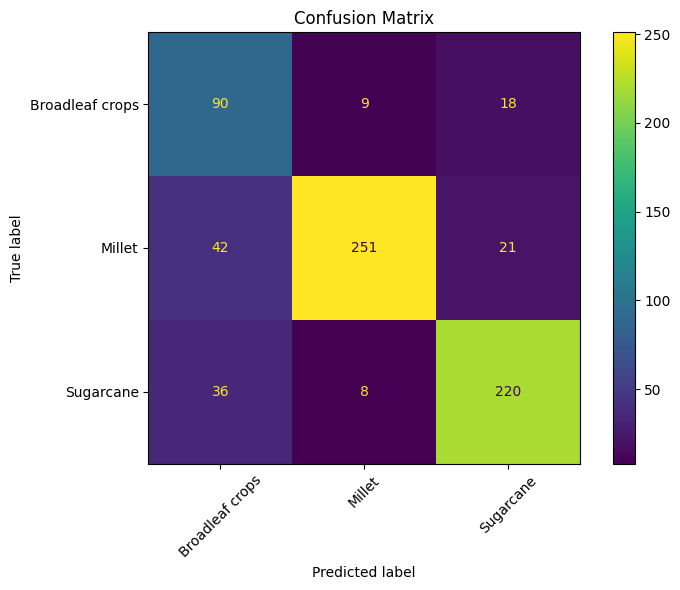

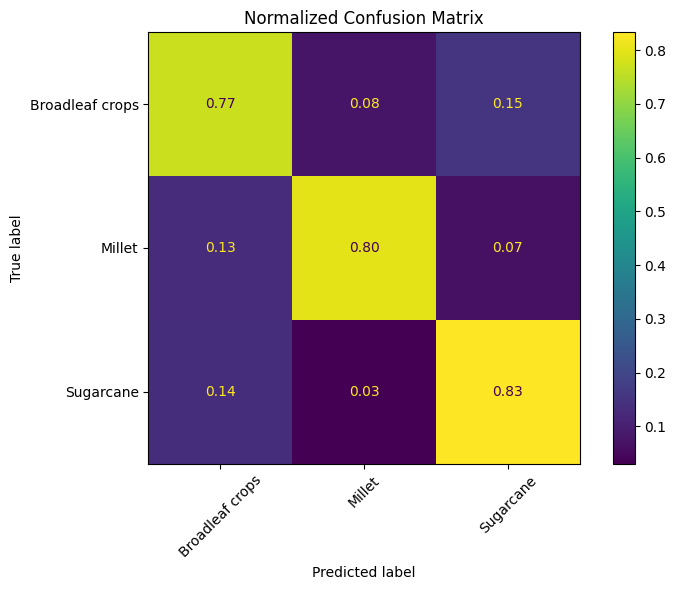

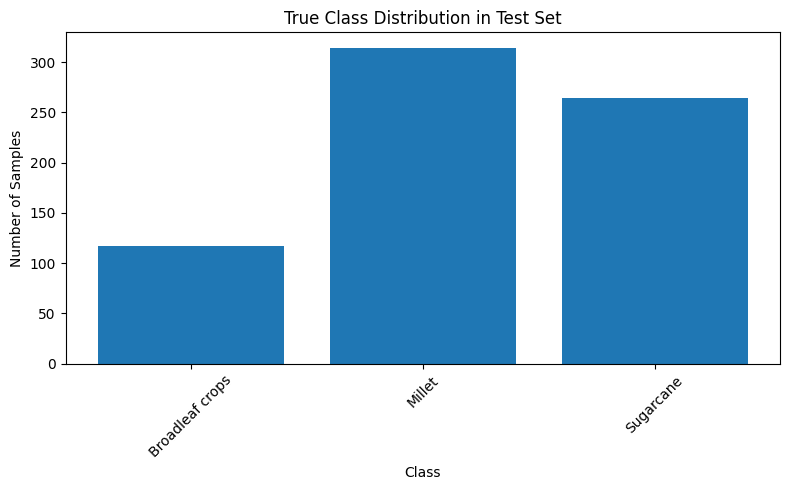

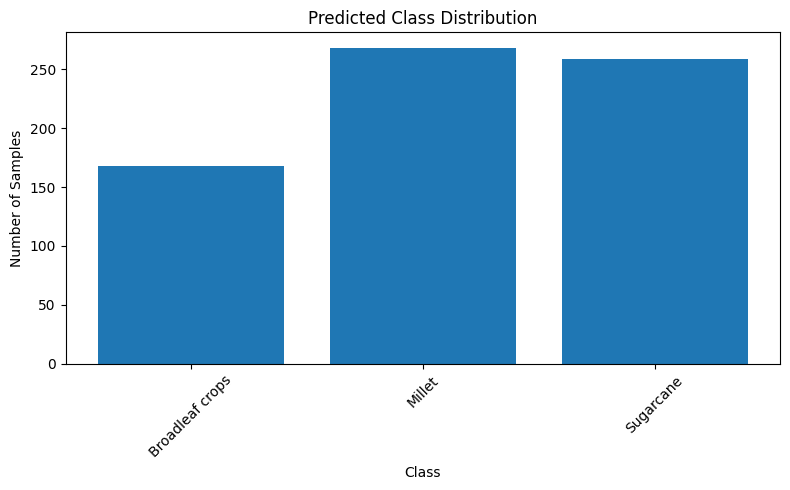

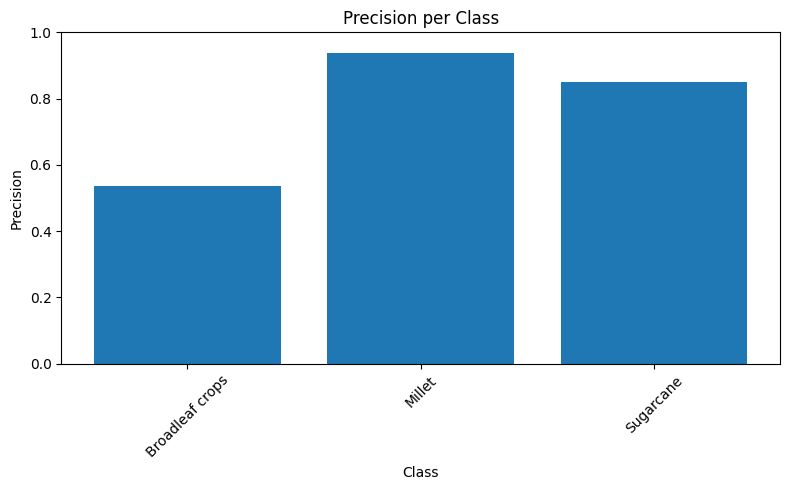

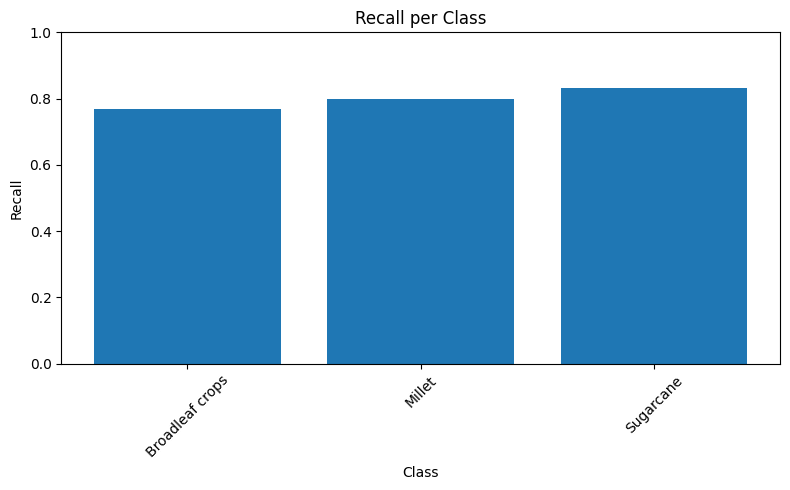

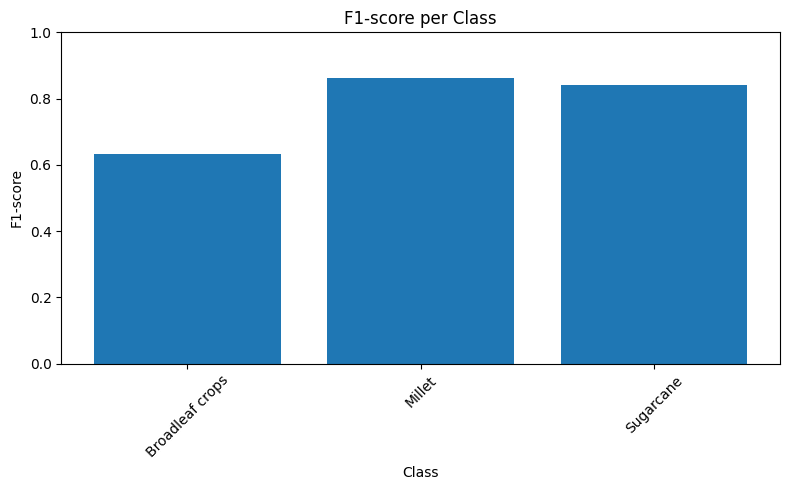

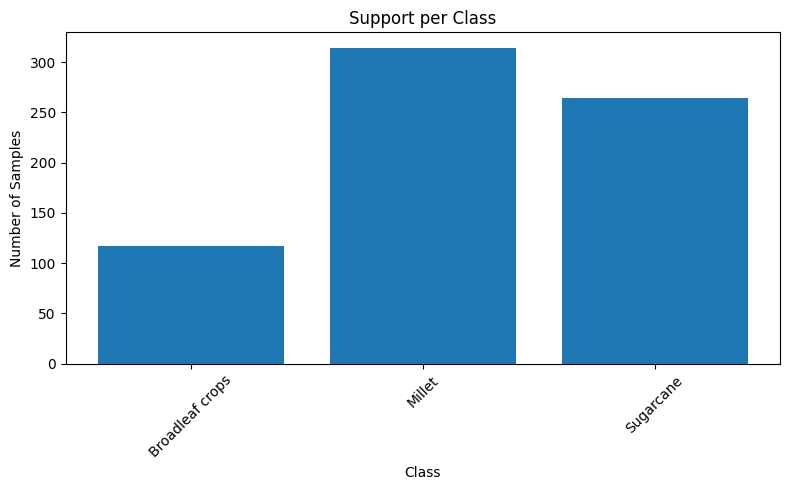

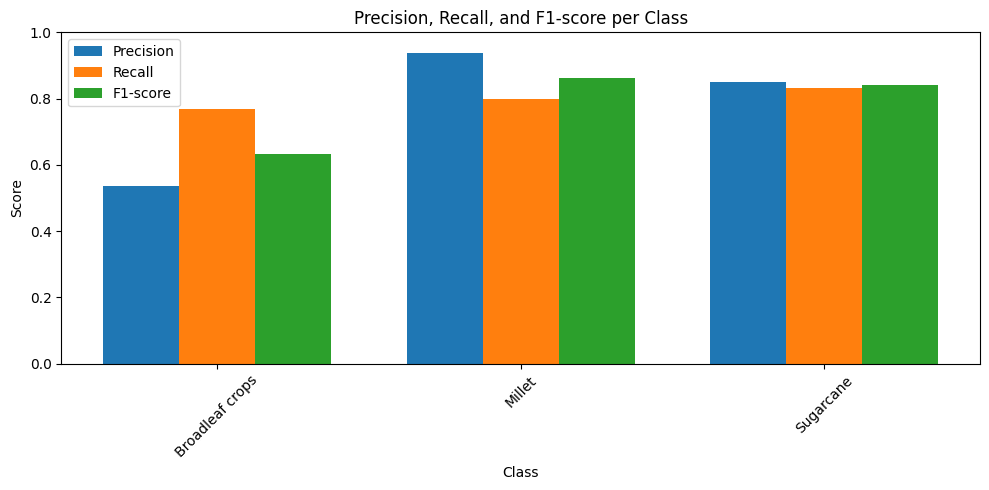

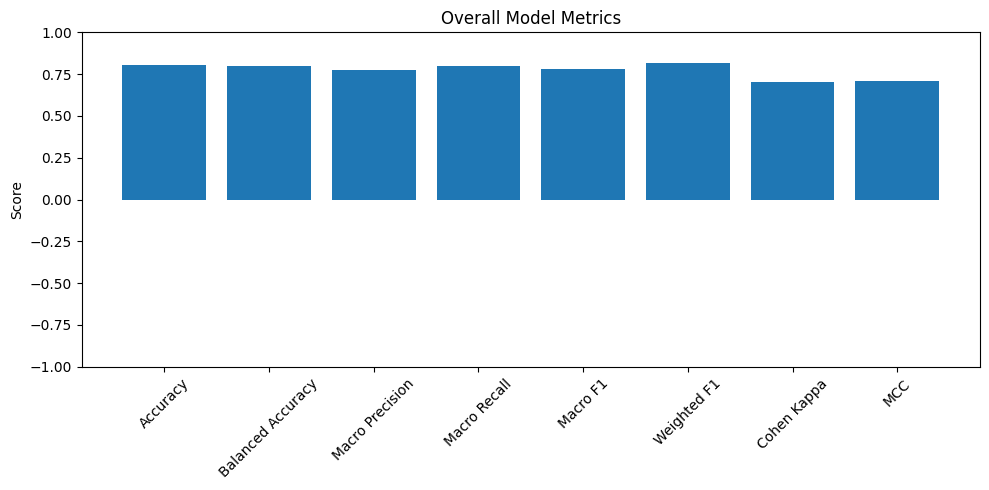


Top Feature Importances


,feature,importance
1,LD2,36.440915
0,LD1,30.735234
4,LD5,13.004969
2,LD3,8.599888
3,LD4,4.915545
5,LD6,3.013878
8,LD9,1.168031
7,LD8,1.137066
6,LD7,0.984475


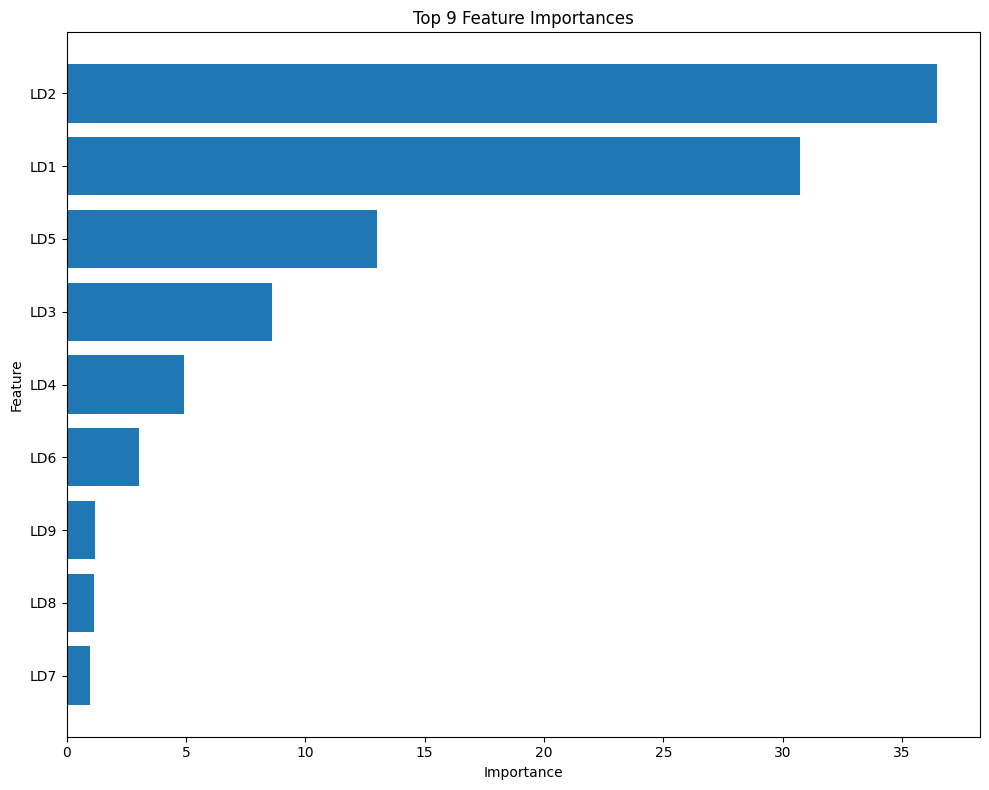


Prediction Probabilities Sample


,proba_Broadleaf crops,proba_Millet,proba_Sugarcane
0,0.538395,0.257362,0.204244
1,0.147185,0.092932,0.759883
2,0.116252,0.822586,0.061162
3,0.101148,0.081741,0.817111
4,0.263626,0.371170,0.365204


In [ ]:
# @title
# ============================================================
# Full Evaluation Code for CatBoost Multi-Class Model
# Works well for imbalanced data
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef
)

# ============================================================
# 1) Class names
# ============================================================

class_names = {
    0: "Broadleaf crops",
    1: "Millet",
    2: "Sugarcane"
}

# ============================================================
# 2) Predictions
# ============================================================

y_test_pred = model.predict(x_test).ravel()

y_test_array = np.array(y_test).ravel()
y_test_pred = np.array(y_test_pred).ravel()

# Try to make prediction dtype same as y_test
try:
    y_test_pred = y_test_pred.astype(y_test_array.dtype)
except:
    pass

# All labels found in test and predictions
labels = np.unique(np.concatenate([y_test_array, y_test_pred]))

# Display labels
display_labels = []
for label in labels:
    try:
        display_labels.append(class_names.get(int(label), str(label)))
    except:
        display_labels.append(str(label))

# ============================================================
# 3) Overall Metrics
# ============================================================

test_accuracy = accuracy_score(y_test_array, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test_array, y_test_pred)

macro_precision = precision_score(
    y_test_array, y_test_pred, average="macro", zero_division=0
)
macro_recall = recall_score(
    y_test_array, y_test_pred, average="macro", zero_division=0
)
macro_f1 = f1_score(
    y_test_array, y_test_pred, average="macro", zero_division=0
)

weighted_precision = precision_score(
    y_test_array, y_test_pred, average="weighted", zero_division=0
)
weighted_recall = recall_score(
    y_test_array, y_test_pred, average="weighted", zero_division=0
)
weighted_f1 = f1_score(
    y_test_array, y_test_pred, average="weighted", zero_division=0
)

kappa = cohen_kappa_score(y_test_array, y_test_pred)
mcc = matthews_corrcoef(y_test_array, y_test_pred)

print("=" * 60)
print("Overall Evaluation")
print("=" * 60)
print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"Macro Precision    : {macro_precision:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1        : {weighted_f1:.4f}")
print(f"Cohen Kappa        : {kappa:.4f}")
print(f"MCC                : {mcc:.4f}")

print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test_array,
        y_test_pred,
        labels=labels,
        target_names=display_labels,
        zero_division=0
    )
)

# ============================================================
# 4) Per-Class Metrics Table
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_array,
    y_test_pred,
    labels=labels,
    zero_division=0
)

metrics_df = pd.DataFrame({
    "class_id": labels,
    "class_name": display_labels,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})

print("\n" + "=" * 60)
print("Per-Class Metrics")
print("=" * 60)
display(metrics_df)

# ============================================================
# 5) Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test_array,
    y_test_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)
disp.plot(values_format="d", ax=ax)
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 6) Normalized Confusion Matrix
# مهم جدًا مع imbalanced data
# ============================================================

cm_norm = confusion_matrix(
    y_test_array,
    y_test_pred,
    labels=labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=display_labels
)
disp.plot(values_format=".2f", ax=ax)
plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 7) Class Distribution: True Labels
# ============================================================

true_counts = pd.Series(y_test_array).value_counts().sort_index()

true_dist_df = pd.DataFrame({
    "class_id": true_counts.index,
    "count": true_counts.values
})

true_dist_df["class_name"] = true_dist_df["class_id"].apply(
    lambda x: class_names.get(int(x), str(x)) if str(x).isdigit() else str(x)
)

plt.figure(figsize=(8, 5))
plt.bar(true_dist_df["class_name"], true_dist_df["count"])
plt.title("True Class Distribution in Test Set")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 8) Class Distribution: Predicted Labels
# ============================================================

pred_counts = pd.Series(y_test_pred).value_counts().sort_index()

pred_dist_df = pd.DataFrame({
    "class_id": pred_counts.index,
    "count": pred_counts.values
})

pred_dist_df["class_name"] = pred_dist_df["class_id"].apply(
    lambda x: class_names.get(int(x), str(x)) if str(x).isdigit() else str(x)
)

plt.figure(figsize=(8, 5))
plt.bar(pred_dist_df["class_name"], pred_dist_df["count"])
plt.title("Predicted Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 9) Precision per Class
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(metrics_df["class_name"], metrics_df["precision"])
plt.title("Precision per Class")
plt.xlabel("Class")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 10) Recall per Class
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(metrics_df["class_name"], metrics_df["recall"])
plt.title("Recall per Class")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 11) F1-score per Class
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(metrics_df["class_name"], metrics_df["f1_score"])
plt.title("F1-score per Class")
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 12) Support per Class
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(metrics_df["class_name"], metrics_df["support"])
plt.title("Support per Class")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 13) Combined Precision / Recall / F1 Graph
# ============================================================

x = np.arange(len(metrics_df))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, metrics_df["precision"], width, label="Precision")
plt.bar(x, metrics_df["recall"], width, label="Recall")
plt.bar(x + width, metrics_df["f1_score"], width, label="F1-score")

plt.xticks(x, metrics_df["class_name"], rotation=45)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score per Class")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 14) Overall Metrics Graph
# ============================================================

overall_metrics = {
    "Accuracy": test_accuracy,
    "Balanced Accuracy": balanced_acc,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1,
    "Cohen Kappa": kappa,
    "MCC": mcc
}

plt.figure(figsize=(10, 5))
plt.bar(overall_metrics.keys(), overall_metrics.values())
plt.title("Overall Model Metrics")
plt.ylabel("Score")
plt.ylim(-1, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 15) Feature Importance
# ============================================================

try:
    feature_importance = model.get_feature_importance()

    if hasattr(x_test, "columns"):
        feature_names = x_test.columns
    else:
        feature_names = [f"feature_{i}" for i in range(x_test.shape[1])]

    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": feature_importance
    }).sort_values("importance", ascending=False)

    print("\n" + "=" * 60)
    print("Top Feature Importances")
    print("=" * 60)
    display(fi_df.head(30))

    top_n = min(30, len(fi_df))

    plt.figure(figsize=(10, 8))
    plt.barh(
        fi_df.head(top_n)["feature"][::-1],
        fi_df.head(top_n)["importance"][::-1]
    )
    plt.title(f"Top {top_n} Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Feature importance could not be calculated.")
    print("Error:", e)

# ============================================================
# 16) Optional: Prediction Probabilities
# ============================================================

try:
    y_test_proba = model.predict_proba(x_test)

    proba_df = pd.DataFrame(
        y_test_proba,
        columns=[f"proba_{name}" for name in display_labels]
    )

    print("\n" + "=" * 60)
    print("Prediction Probabilities Sample")
    print("=" * 60)
    display(proba_df.head())

except Exception as e:
    print("Prediction probabilities could not be calculated.")
    print("Error:", e)

## **Inferance for second model**

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline


def inference(df: pd.DataFrame, pipe, model) -> dict:
    label_map = {
        0: "Broadleaf crops",
        1: "Millet",
        2: "Sugarcane"
    }

    ld_columns = [
        "LD1", "LD2", "LD3", "LD4", "LD5",
        "LD6", "LD7", "LD8", "LD9"
    ]

    # ----------------------------
    # Validate input
    # ----------------------------
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame.")

    if len(df) != 1:
        raise ValueError("df must contain exactly one row.")

    df = df.copy()

    # ----------------------------
    # Get columns expected by pipe
    # ----------------------------
    if hasattr(pipe, "feature_names_in_"):
        pipe_columns = list(pipe.feature_names_in_)
    else:
        pipe_columns = [
            "N", "P", "K", "Soil_pH", "Soil_Moisture", "Soil_Type",
            "Organic_Carbon", "Electrical_Conductivity", "Temperature", "Humidity",
            "Rainfall", "Sunlight_Hours", "Wind_Speed", "Region", "Altitude",
            "Season", "Irrigation_Type", "Fertilizer_Used", "Previous_Crop"
        ]

    missing_cols = [col for col in pipe_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns required by pipe: {missing_cols}")

    df = df[pipe_columns].copy()

    # ----------------------------
    # Clean raw input
    # ----------------------------
    df = df.replace(
        ["", " ", "None", "none", "NULL", "null", "NaN", "nan"],
        np.nan
    )

    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].fillna("Unknown")
            df[col] = df[col].astype(str).str.strip()
            df[col] = df[col].astype(object)
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(0)

    if df.isna().any().any():
        raise ValueError(
            f"NaN still exists before pipe in columns: "
            f"{df.columns[df.isna().any()].tolist()}"
        )

    # ----------------------------
    # Helper: remove NaN from arrays/dataframes
    # ----------------------------
    def fix_nan(X):
        if isinstance(X, pd.DataFrame):
            return X.fillna(0)

        X = np.asarray(X)

        if np.isnan(X).any():
            X = np.nan_to_num(
                X,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

        return X

    # ----------------------------
    # Transform with pipe safely
    # ----------------------------
    try:
        if isinstance(pipe, Pipeline):
            X = df.copy()

            for step_name, step in pipe.steps:
                X = step.transform(X)
                X = fix_nan(X)

            transformed = X

        else:
            transformed = pipe.transform(df)
            transformed = fix_nan(transformed)

    except Exception as e:
        print("Input sent to pipe:")
        print(df)

        print("\nInput dtypes:")
        print(df.dtypes)

        if isinstance(pipe, Pipeline):
            print("\nPipe steps:")
            print(pipe.steps)

        raise RuntimeError(f"Pipe transform failed: {e}")

    # ----------------------------
    # Convert transformed output to DataFrame
    # ----------------------------
    if isinstance(transformed, pd.DataFrame):
        transformed_df = transformed.copy()
    else:
        transformed = np.asarray(transformed)

        if transformed.ndim == 1:
            transformed = transformed.reshape(1, -1)

        if transformed.shape[1] != len(ld_columns):
            raise ValueError(
                f"Pipe output has {transformed.shape[1]} columns, "
                f"but expected {len(ld_columns)} columns."
            )

        transformed_df = pd.DataFrame(transformed, columns=ld_columns)

    # Ensure LD column names
    if transformed_df.shape[1] == len(ld_columns):
        transformed_df.columns = ld_columns

    transformed_df = transformed_df[ld_columns].copy()

    for col in ld_columns:
        transformed_df[col] = pd.to_numeric(transformed_df[col], errors="coerce")

    transformed_df = transformed_df.fillna(0)

    # ----------------------------
    # Predict
    # ----------------------------
    try:
        pred = model.predict(transformed_df)
    except Exception as e:
        print("Data sent to model:")
        print(transformed_df)

        print("\nData sent to model dtypes:")
        print(transformed_df.dtypes)

        raise RuntimeError(f"model.predict failed: {e}")

    label_num = int(pred[0])
    label_name = label_map.get(label_num, "Unknown")

    return {
        'label': label_num,
        'label_name': label_name
    }

In [14]:
test_raw = pd.read_csv(TEST_DATA_PATH)

sample_row = test_raw.drop("Recommended_Crop", axis=1).iloc[[1]].copy()

In [16]:
sample_row

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Irrigation_Type,Fertilizer_Used,Previous_Crop
1,57,53,37,5.98,34.85,Clay,0.47,1.14,13.72,42.61,1569.01,4.15,12.25,East,779,Kharif,Drip,270.76,Cotton


In [17]:
sample_row.to_csv('tst.csv' , index = False)

In [ ]:
result = inference(sample_row, pipe, loaded_second_model)
print(result)

{'label': 1, 'label_name': 'Millet'}


/tmp/ipykernel_44253/2565567351.py:165: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_num = int(pred[0])
